Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 32,065 rows and 22 columns.
Retained 21 feature columns:
  vehicle_gps_latitude
  vehicle_gps_longitude
  fuel_consumption_rate
  eta_variation_hours
  traffic_congestion_level
  warehouse_inventory_level
  loading_unloading_time
  handling_equipment_availability
  order_fulfillment_status
  weather_condition_severity
  port_congestion_level
  shipping_costs
  supplier_reliability_score
  lead_time_days
  historical_demand
  iot_temperature
  cargo_condition_status
  route_risk_level
  customs_clearance_time
  driver_behavior_score
  fatigue_monitoring_score

Non-numeric columns: none

Columns with missing values:
  none

Five lowest-variance columns:
cargo_condition_status             0.103434
handling_equipment_availability    0.106220
order_fulfillment_status           0.119489
fatigue_monitoring_score           0.119585
weather_condition_severity  

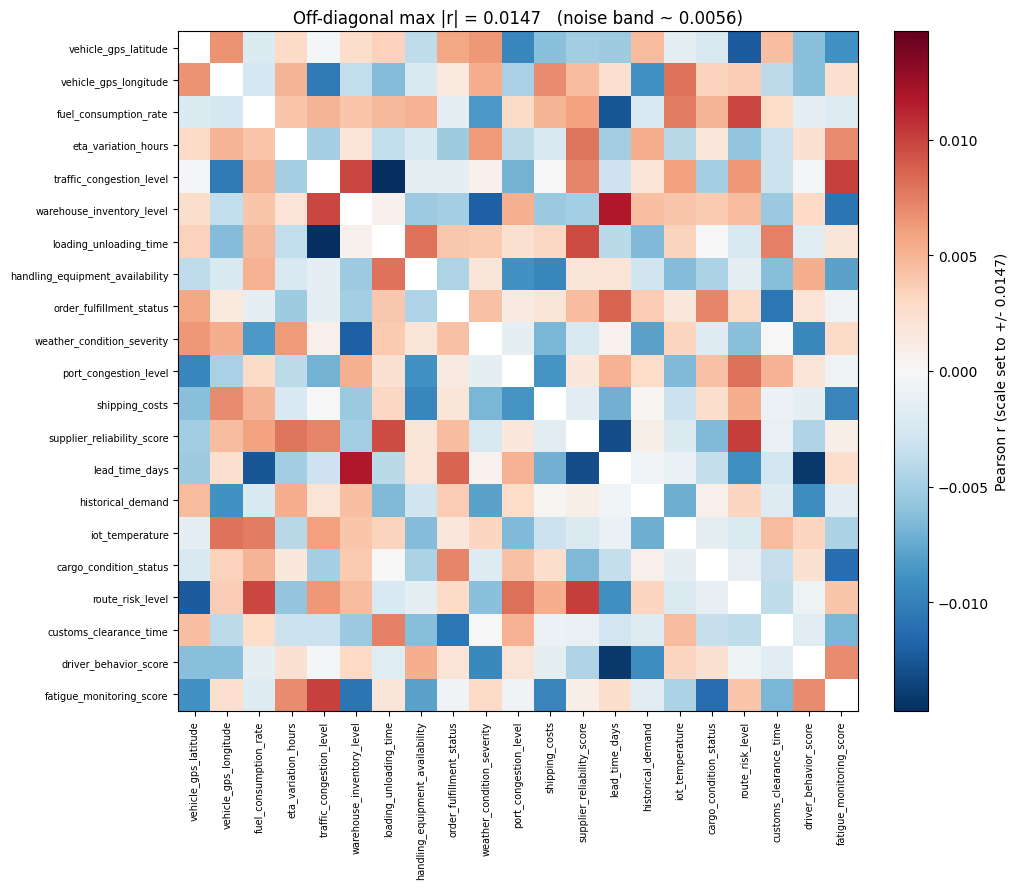

In [4]:
# ======================================================================
# Correlation diagnostic for the logistics dataset (21 retained features)
# ======================================================================

# ===  Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')


# === Imports and configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE_DIR = '/content/drive/MyDrive/SCMLLM' #path google drive
CSV_PATH   = os.path.join(BASE_DIR, "finalized_dynamic_supply_chain_logistics.csv")


# Excluded from the input space: the timestamp index and the four predictive target variables (retaining them would cause target leakage).
TIMESTAMP_COL = 'timestamp'
TARGET_COLS = [
    'disruption_likelihood_score',
    'delay_probability',
    'risk_classification',
    'delivery_time_deviation',
]


# === Load and assemble the 21-feature input matrix ===
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} rows and {df.shape[1]} columns.')

drop_cols = [TIMESTAMP_COL] + TARGET_COLS
features = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f'Retained {features.shape[1]} feature columns:')
for c in features.columns:
    print(f'  {c}')


# === Integrity checks before correlating ===
# 1) Any column read as text is silently dropped by .corr()
non_numeric = features.select_dtypes(exclude='number').columns.tolist()
print('\nNon-numeric columns:', non_numeric if non_numeric else 'none')

# Coerce anything stored as text to numeric so nothing drops out unnoticed.
features = features.apply(pd.to_numeric, errors='coerce')

# 2) Missing values, whether pre-existing or introduced by coercion.
missing = features.isna().sum()
print('\nColumns with missing values:')
print(missing[missing > 0] if missing.any() else '  none')

# 3) Constant or near-constant columns. A zero-variance column returns undefined correlations that can show up as zeros.
variances = features.var(numeric_only=True)
print('\nFive lowest-variance columns:')
print(variances.sort_values().head().to_string())
constant = variances[variances == 0].index.tolist()
print('Zero-variance (constant) columns:', constant if constant else 'none')


# === Full-precision Pearson correlation ===
corr = features.corr(method='pearson')

# Off-diagonal values only (the diagonal is a trivial 1.0).
mask = ~np.eye(corr.shape[0], dtype=bool)
off_diag = corr.where(mask)
max_abs = off_diag.abs().max().max()

n = len(features.dropna())
noise_band = 1 / np.sqrt(n)

print(f'\nRecords used (complete rows): {n:,}')
print(f'Expected sampling-noise band (1/sqrt(n)): {noise_band:.5f}')
print(f'Maximum absolute off-diagonal correlation: {max_abs:.6f}')

flat = off_diag.abs().stack()
print('\nOff-diagonal pairs exceeding reference thresholds:')
for t in [0.005, 0.01, 0.02, 0.05, 0.10]:
    print(f'  |r| > {t:<5}: {int((flat > t).sum())} of {flat.size} pairs')


# === Strongest off-diagonal pairs, full precision ===
# stack() lists each pair twice; iloc[::2] keeps one copy of each.
pairs = off_diag.abs().stack().sort_values(ascending=False)
top = pairs.iloc[::2].head(15)
print('\nTop 15 feature pairs by absolute correlation:')
for (a, b), _ in top.items():
    print(f'  {a:<34} {b:<34} {corr.loc[a, b]:+.6f}')


# === Heatmap (diagonal hidden, colour scale set to the data) ===
display_corr = corr.values.astype(float).copy()
np.fill_diagonal(display_corr, np.nan)

scale = max(max_abs, 1e-6)                     # adapt range so any structure shows
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad('white')                          # NaN diagonal renders white

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(display_corr, cmap=cmap, vmin=-scale, vmax=scale)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(f'Pearson r (scale set to +/- {scale:.4f})')
ax.set_title(f'Off-diagonal max |r| = {max_abs:.4f}   '
             f'(noise band ~ {noise_band:.4f})')
plt.tight_layout()
plt.savefig('/content/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

